# 0. 神经网络基础 —— 激活函数 · 手搓全连接网络 · 反向传播 · 优化器

这是 Transformer 系列的前置基础讲（本讲 0 号，后面 1-9 讲都是神经网络大厦的"上层建筑"）。
目标是让你**亲手从零实现**一个能学习的神经网络：

1. 神经元与激活函数（ReLU / Sigmoid / Tanh / GELU / SiLU）
2. 全连接层 forward / **backward（反向传播，链式法则）**
3. 损失与梯度
4. **优化器**：SGD / Momentum / Adam（手搓更新公式）
5. 用它训练一个模型拟合 sin 曲线（有 loss 曲线、有拟合结果）
6. **梯度消失**现象可视化（为什么深层网络要换激活函数）

> 学完本讲，再看第 4 讲（FFN）和第 9 讲（MiniMind），会发现 Transformer 的
> FeedForward 就是"全连接网络"，训练就是"反传 + 优化器"——一切基础都在这里。


## 1. 神经元与激活函数

单个神经元：$y = f(x\cdot w + b)$，其中 $f$ 是**激活函数**（非线性）。没有非线性，
多层网络就退化成一层线性变换——所以激活函数是深度的来源。

| 激活 | 公式 | 导数 |
|---|---|---|
| ReLU | $\max(0,x)$ | $1[x>0]$ |
| Sigmoid | $\sigma(x)=\dfrac{1}{1+e^{-x}}$ | $\sigma(1-\sigma)$ |
| Tanh | $\tanh x$ | $1-\tanh^2x$ |
| GELU | $0.5x(1+\tanh(a)),\ a=\sqrt{2/\pi}(x+0.044715x^3)$ | $0.5(1+\tanh a)+0.5x(1-\tanh^2a)\cdot\sqrt{2/\pi}(1+3\cdot0.044715x^2)$ |
| SiLU | $x\sigma(x)$ | $\sigma(x)+x\sigma(x)(1-\sigma(x))$ |

全部手搓 forward + 解析导数，并用**中心有限差分** $(f(x+h)-f(x-h))/2h$ 验证导数正确。


In [1]:
import numpy as np
import torch
import torch.nn as nn
import math

np.random.seed(0)
torch.manual_seed(0)

def relu(x):  return np.maximum(x, 0.0)
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def tanh(x): return np.tanh(x)
def gelu(x):
    a = math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)
    return 0.5 * x * (1.0 + np.tanh(a))
def silu(x): return x * (1.0 / (1.0 + np.exp(-x)))

# 解析导数
def d_relu(x):  return (x > 0).astype(float)
def d_sigmoid(x): s = sigmoid(x); return s * (1 - s)
def d_tanh(x):  return 1.0 - np.tanh(x) ** 2
def d_gelu(x):
    a = math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)
    t = np.tanh(a)
    return 0.5 * (1 + t) + 0.5 * x * (1 - t ** 2) * math.sqrt(2.0 / math.pi) * (1 + 3 * 0.044715 * x ** 2)
def d_silu(x): s = sigmoid(x); return s + x * s * (1 - s)

xs = np.linspace(-3, 3, 2001)
xs = xs[np.abs(xs) > 1e-8]                 # 避开 x=0：ReLU 在 0 点不可导（左导 0、右导 1），教学上网格跳过
acts = {'ReLU': (relu, d_relu), 'Sigmoid': (sigmoid, d_sigmoid), 'Tanh': (tanh, d_tanh),
        'GELU': (gelu, d_gelu), 'SiLU': (silu, d_silu)}
print('激活函数导数 · 中心有限差分验证（阈值 1e-5）：')
for name, (f, df) in acts.items():
    h = 1e-6
    fd = (f(xs + h) - f(xs - h)) / (2 * h)      # 数值导数
    err = np.abs(fd - df(xs)).max()             # 与解析导数对比
    assert err < 1e-5, (name, err)
    print(f'  {name:8s} :  max err = {err:.3e}   ->  PASS')


激活函数导数 · 中心有限差分验证（阈值 1e-5）：
  ReLU     :  max err = 1.398e-10   ->  PASS
  Sigmoid  :  max err = 1.263e-10   ->  PASS
  Tanh     :  max err = 7.740e-11   ->  PASS
  GELU     :  max err = 4.620e-10   ->  PASS
  SiLU     :  max err = 6.881e-10   ->  PASS


### 激活函数与导数曲线（讲课用：每个函数一条 f 一条 f′）


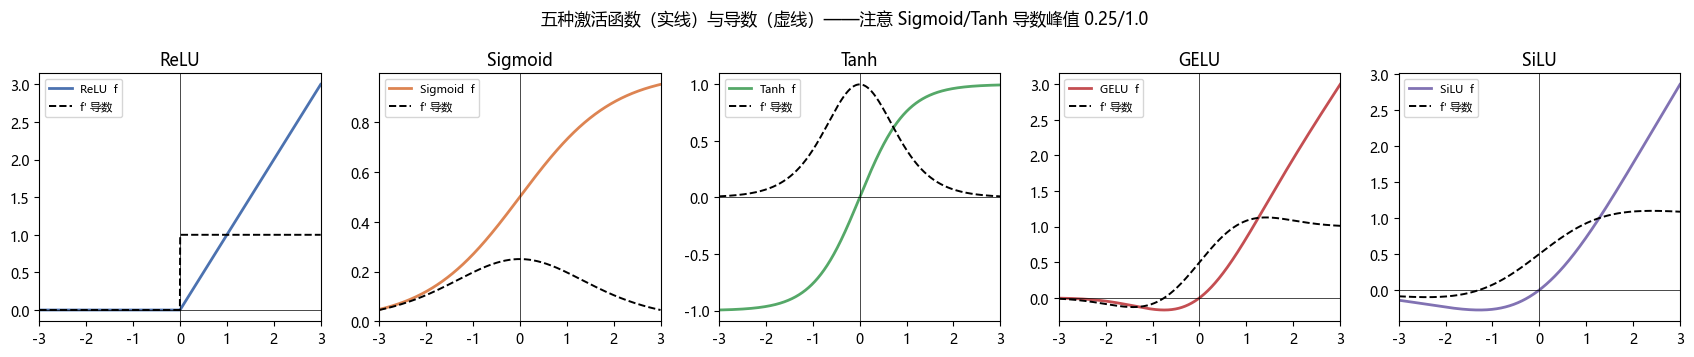

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for ax, ((name, (f, df)), col) in zip(axes, zip(acts.items(), colors)):
    ax.plot(xs, f(xs), col, lw=2, label=f'{name}  f')
    ax.plot(xs, df(xs), 'k--', lw=1.4, label='f\' 导数')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8); ax.set_xlim(-3, 3)
fig.suptitle('五种激活函数（实线）与导数（虚线）——注意 Sigmoid/Tanh 导数峰值 0.25/1.0', fontsize=12)
plt.tight_layout(); plt.show()


## 2. 全连接层（Affine）与反向传播

**全连接层**（也叫线性层/Affine）：$y = xW + b$，其中 $x:[B,N_{in}]$、$W:[N_{in},N_{out}]$、$b:[N_{out}]$。

**反向传播**就是链式法则：已知上游梯度 $\dfrac{\partial L}{\partial y}$，求三个梯度

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y}W^T,\qquad
\frac{\partial L}{\partial W} = x^T\frac{\partial L}{\partial y},\qquad
\frac{\partial L}{\partial b} = \sum_{batch}\frac{\partial L}{\partial y}$$

直觉：$dW$ 是"输入与上游梯度的外积之和"，$dx$ 是"上游梯度沿 $W^T$ 往回投影"。
下面手搓并用有限差分验证（每个元素都对比解析梯度）。


In [3]:
def linear_forward(x, W, b):
    """y = x@W + b。x [B,in]，W [in,out]（手搓约定：行=输入、列=输出）。"""
    return x @ W + b

def linear_backward(dy, x, W):
    """反传：dx = dy@W.T；dW = xᵀ@dy（对 batch 求和）；db = 对 batch 求和。"""
    dx = dy @ W.T
    dW = x.T @ dy
    db = dy.sum(axis=0, keepdims=True)
    return dx, dW, db

# ---- 有限差分全元素验证 ----
B, Ni, No = 3, 4, 5
x = np.random.randn(B, Ni); W = np.random.randn(Ni, No); b = np.random.randn(1, No)
dy = np.random.randn(B, No)
dx, dW, db = linear_backward(dy, x, W)
eps = 1e-6
# 对 W[1,2] 数值求导
Wp = W.copy(); Wp[1, 2] += eps; Wm = W.copy(); Wm[1, 2] -= eps
fd_W = ((linear_forward(x, Wp, b) - linear_forward(x, Wm, b)) * dy).sum() / (2 * eps)
# 对 b[0,3] 数值求导
bp = b.copy(); bp[0, 3] += eps; bm = b.copy(); bm[0, 3] -= eps
fd_b = ((linear_forward(x, W, bp) - linear_forward(x, W, bm)) * dy).sum() / (2 * eps)
# 对 x[1,0] 数值求导
xp = x.copy(); xp[1, 0] += eps; xm = x.copy(); xm[1, 0] -= eps
fd_x = ((linear_forward(xp, W, b) - linear_forward(xm, W, b)) * dy).sum() / (2 * eps)
assert abs(fd_W - dW[1, 2]) < 1e-5 and abs(fd_b - db[0, 3]) < 1e-5 and abs(fd_x - dx[1, 0]) < 1e-5
print(f'有限差分: dW[1,2] = {fd_W:.6e} vs 解析 {dW[1,2]:.6e}  ->  PASS')
print(f'有限差分: db[0,3] = {fd_b:.6e} vs 解析 {db[0,3]:.6e}  ->  PASS')
print(f'有限差分: dx[1,0] = {fd_x:.6e} vs 解析 {dx[1,0]:.6e}  ->  PASS')


有限差分: dW[1,2] = 2.897523e-01 vs 解析 2.897523e-01  ->  PASS
有限差分: db[0,3] = -2.382094e+00 vs 解析 -2.382094e+00  ->  PASS
有限差分: dx[1,0] = -3.305341e+00 vs 解析 -3.305341e+00  ->  PASS


## 3. 手搓两层全连接网络（MLP）——完整反向传播

网络：$x \to W_1,b_1 \to \text{Tanh} \to W_2,b_2 \to \hat y$，损失用均方误差 $\mathcal{L}=\frac{1}{N}\sum(\hat y-y)^2$。

反传路径（链式法则一步步往回走）：

$$\frac{\partial\mathcal L}{\partial y} = \frac{2(\hat y - y)}{N}\ \to\ \frac{\partial\mathcal L}{\partial W_2},\ \frac{\partial\mathcal L}{\partial h}\ \to\ \frac{\partial\mathcal L}{\partial z_1}(\text{Tanh 导数})\ \to\ \frac{\partial\mathcal L}{\partial W_1},\ \frac{\partial\mathcal L}{\partial b_1}$$

并用 torch（同结构同权重 + autograd）做全梯度对照。输入输出用 1 维 → 隐藏 8 → 1（与后面的 sin 拟合任务同结构）。


In [4]:
def mlp_forward(x, W1, b1, W2, b2):
    """两层 MLP forward。x [B,1]；W1 [1,8]；W2 [8,1]。返回 (y_hat, cache)。"""
    z1 = x @ W1 + b1                 # [B,8] 隐藏层预激活
    h1 = np.tanh(z1)                 # Tanh 激活
    y_hat = h1 @ W2 + b2             # [B,1] 输出
    return y_hat, (x, z1, h1)

def mlp_backward(dy, cache, W1, W2):
    """MLP 反传（链式法则）。dy = dL/dy_hat [B,1]。返回各参数梯度。"""
    x, z1, h1 = cache
    dW2 = h1.T @ dy; db2 = dy.sum(0, keepdims=True)      # 输出层
    dh1 = dy @ W2.T                                      # 梯度穿过 W2
    dz1 = dh1 * (1 - h1 ** 2)                            # Tanh 导数（1 - h²）
    dW1 = x.T @ dz1; db1 = dz1.sum(0, keepdims=True)     # 隐藏层
    return dW1, db1, dW2, db2

# ---- 与 torch autograd 全梯度对照 ----
d_in, d_h, d_out = 1, 8, 1
B = 16
rng = np.random.default_rng(1)
W1 = rng.standard_normal((d_in, d_h)) * 0.5
b1 = rng.standard_normal((1, d_h)) * 0.1
W2 = rng.standard_normal((d_h, d_out)) * 0.5
b2 = rng.standard_normal((1, d_out)) * 0.1
x = np.linspace(0, 2 * math.pi, B).reshape(-1, 1)        # 输入 0~2π
y = np.sin(x) + 0.05 * np.random.randn(B, 1)             # 目标 sin + 噪声

y_hat, cache = mlp_forward(x, W1, b1, W2, b2)
loss = np.mean((y_hat - y) ** 2)
dy = 2 * (y_hat - y) / B
dW1, db1, dW2, db2 = mlp_backward(dy, cache, W1, W2)

# torch：同样的权重、同样的前向
lin1 = nn.Linear(d_in, d_h, dtype=torch.float64); lin1.weight.data = torch.tensor(W1.T); lin1.bias.data = torch.tensor(b1[0])
lin2 = nn.Linear(d_h, d_out, dtype=torch.float64); lin2.weight.data = torch.tensor(W2.T); lin2.bias.data = torch.tensor(b2[0])
xt = torch.tensor(x, dtype=torch.float64, requires_grad=True)
t = lin2(torch.tanh(lin1(xt)))
loss_t = torch.mean((t - torch.tensor(y, dtype=torch.float64)) ** 2)
loss_t.backward()
errs = [float(np.abs(dW1 - lin1.weight.grad.numpy().T).max()),
        float(np.abs(db1 - lin1.bias.grad.numpy().reshape(1, -1)).max()),
        float(np.abs(dW2 - lin2.weight.grad.numpy().T).max()),
        float(np.abs(db2 - lin2.bias.grad.numpy().reshape(1, -1)).max())]
assert all(e < 1e-8 for e in errs), errs
print(f'手搓 loss = {loss:.6f}  vs  torch loss = {float(loss_t.item()):.6f}   ->  PASS')
print(f'梯度对照: dW1 {errs[0]:.2e} | db1 {errs[1]:.2e} | dW2 {errs[2]:.2e} | db2 {errs[3]:.2e}   ->  PASS')


手搓 loss = 0.665437  vs  torch loss = 0.665437   ->  PASS
梯度对照: dW1 2.22e-16 | db1 2.22e-16 | dW2 1.11e-16 | db2 0.00e+00   ->  PASS


## 4. 优化器：SGD / Momentum / Adam

训练 = 用梯度更新参数。三个经典更新规则（$g$=梯度，$\eta$=学习率，$\beta,\beta_1,\beta_2$=超参）：

**SGD**：$w \leftarrow w - \eta\, g$

**Momentum**：$v \leftarrow \beta v + g$，$w \leftarrow w - \eta\, v$（沿历史梯度"惯性"前进，越过平坦区）

**Adam**（自适应矩估计）：$m\leftarrow\beta_1 m+(1-\beta_1)g$，$v\leftarrow\beta_2 v+(1-\beta_2)g^2$，
$\hat m=\dfrac{m}{1-\beta_1^t}$，$\hat v=\dfrac{v}{1-\beta_2^t}$，$w\leftarrow w-\eta\dfrac{\hat m}{\sqrt{\hat v}+\varepsilon}$
（每个参数有自己的步长，稀疏梯度也稳）

**手搓并训练同一个 MLP 拟合 sin 曲线**：相同初始化、相同数据、相同步数，对比三种优化器的收敛速度。


In [5]:
class SGD:
    def __init__(self, lr=0.02): self.lr = lr
    def step(self, params, grads, state, t):
        for k in params:
            params[k] -= self.lr * grads[k]          # w ← w − η·g

class Momentum:
    def __init__(self, lr=0.02, beta=0.9): self.lr, self.beta = lr, beta
    def step(self, params, grads, state, t):
        for k in params:
            v = state.setdefault(k, np.zeros_like(params[k]))
            v[...] = self.beta * v + grads[k]        # v ← βv + g
            params[k] -= self.lr * v                 # w ← w − η·v

class Adam:
    def __init__(self, lr=0.02, b1=0.9, b2=0.999, eps=1e-8): self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
    def step(self, params, grads, state, t):
        for k in params:
            m = state.setdefault('m' + k, np.zeros_like(params[k]))
            v = state.setdefault('v' + k, np.zeros_like(params[k]))
            m[...] = self.b1 * m + (1 - self.b1) * grads[k]       # 一阶矩
            v[...] = self.b2 * v + (1 - self.b2) * grads[k] ** 2  # 二阶矩
            mhat = m / (1 - self.b1 ** t); vhat = v / (1 - self.b2 ** t)   # 偏差校正
            params[k] -= self.lr * mhat / (np.sqrt(vhat) + self.eps)       # w ← w − η·m̂/(√v̂+ε)

def train(opt, steps=2500, seed=0):
    """用给定优化器训练上面的 MLP 拟合 sin（相同初始化、相同数据）。返回 loss 历史。"""
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((1, 8)) * 0.5; b1 = rng.standard_normal((1, 8)) * 0.1
    W2 = rng.standard_normal((8, 1)) * 0.5; b2 = rng.standard_normal((1, 1)) * 0.1
    params = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
    state = {}; history = []
    for t in range(1, steps + 1):
        y_hat, cache = mlp_forward(x, params['W1'], params['b1'], params['W2'], params['b2'])
        loss = np.mean((y_hat - y) ** 2)
        dy = 2 * (y_hat - y) / B
        g = mlp_backward(dy, cache, params['W1'], params['W2'])
        grads = dict(zip(['W1', 'b1', 'W2', 'b2'], g))   # 完整梯度字典（键与 params 一致）
        opt.step(params, grads, state, t)                # 一步更新全部参数
        history.append(loss)
        if t % 500 == 0:
            print(f'  {type(opt).__name__:9s} step {t:4d}  loss = {loss:.5f}')
    return history, params

print('三种优化器各训练 2500 步（学习率 0.02）：')
hist_sgd, p_sgd = train(SGD(0.02), seed=0)
hist_mom, p_mom = train(Momentum(0.02), seed=0)
hist_adam, p_adam = train(Adam(0.02), seed=0)


三种优化器各训练 2500 步（学习率 0.02）：
  SGD       step  500  loss = 0.16367
  SGD       step 1000  loss = 0.11000
  SGD       step 1500  loss = 0.09414


  SGD       step 2000  loss = 0.08716


  SGD       step 2500  loss = 0.08287


  Momentum  step  500  loss = 0.06765
  Momentum  step 1000  loss = 0.02107
  Momentum  step 1500  loss = 0.00254


  Momentum  step 2000  loss = 0.00131


  Momentum  step 2500  loss = 0.00100
  Adam      step  500  loss = 0.00158


  Adam      step 1000  loss = 0.00065


  Adam      step 1500  loss = 0.00062


  Adam      step 2000  loss = 0.00067
  Adam      step 2500  loss = 0.00060


### 训练结果可视化：loss 曲线 + 拟合曲线


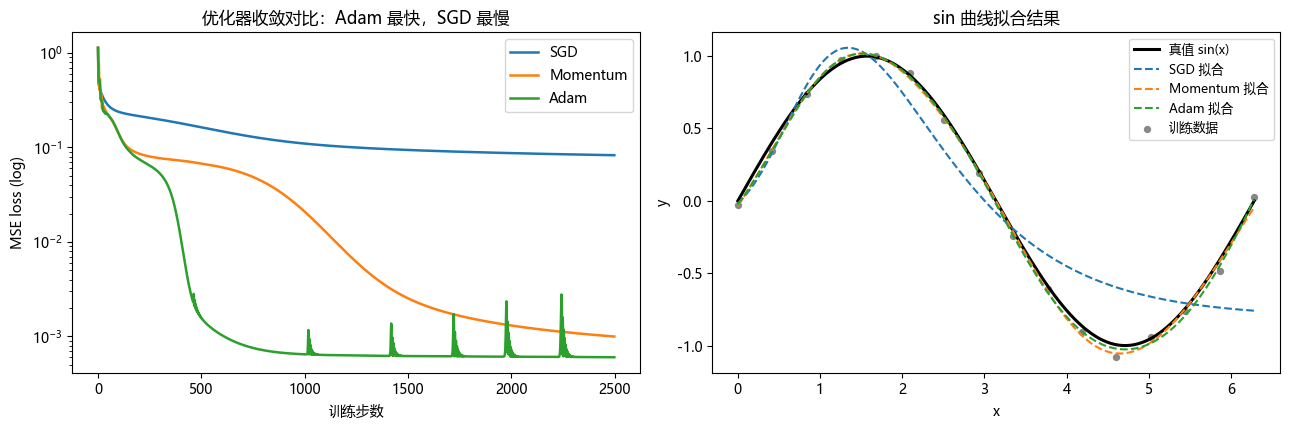

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
for name, h in [('SGD', hist_sgd), ('Momentum', hist_mom), ('Adam', hist_adam)]:
    ax.plot(h, lw=1.8, label=name)
ax.set_yscale('log'); ax.set_xlabel('训练步数'); ax.set_ylabel('MSE loss (log)')
ax.set_title('优化器收敛对比：Adam 最快，SGD 最慢', fontsize=12)
ax.legend()
ax = axes[1]
xs_grid = np.linspace(0, 2 * math.pi, 200).reshape(-1, 1)
ax.plot(xs_grid, np.sin(xs_grid), 'k-', lw=2.2, label='真值 sin(x)')
for name, p in [('SGD', p_sgd), ('Momentum', p_mom), ('Adam', p_adam)]:
    pred, _ = mlp_forward(xs_grid, p['W1'], p['b1'], p['W2'], p['b2'])
    ax.plot(xs_grid, pred, lw=1.5, ls='--', label=f'{name} 拟合')
ax.scatter(x, y, s=18, c='#888', label='训练数据', zorder=0)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('sin 曲线拟合结果', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 5. 梯度消失 —— 为什么深层网络要用 ReLU 而非 Sigmoid

反向传播是**链式乘法**：第 $l$ 层梯度 ∝ 后面每层的 $\|W\| \cdot \|f'(z)\|$ 之积。
Sigmoid 导数最大只有 0.25（Tanh 最大 1），权重再稍小，乘积就**指数级衰减**——深层的梯度趋近于 0，参数几乎不动（梯度消失）。

下面手搓一个 5 层网络（输入 → 隐藏×4 → 输出，激活可换），打印**每一层 |dW| 的梯度范数**：


In [7]:
def deep_net_grad_norms(act, d_act, n_layer=5, seed=3, w_scale=0.5):
    """手搓 n_layer 层全连接网络的反传，返回每层 |dW| 范数（层 0 最接近输入）。"""
    rng = np.random.default_rng(seed)
    d = 8                       # 每层宽度
    x = rng.standard_normal((8, d)) * 0.5
    # 前向，缓存每层预激活与激活值
    h = x; caches = []
    Ws = [rng.standard_normal((d, d)) * w_scale for _ in range(n_layer)]
    bs = [rng.standard_normal((1, d)) * 0.1 for _ in range(n_layer)]
    for W, b in zip(Ws, bs):
        z = h @ W + b; caches.append((h, z, act(z))); h = act(z)
    dy = rng.standard_normal(h.shape) * 0.1            # 模拟来自损失的梯度
    norms = []
    for i in range(n_layer - 1, -1, -1):
        h_prev, z, a = caches[i]
        dz = dy * d_act(z)                             # 过激活导数
        dW = h_prev.T @ dz                             # 该层参数梯度
        norms.append(float(np.linalg.norm(dW)))
        dy = dz @ Ws[i].T                              # 继续往上一层传播
    return list(reversed(norms))                        # 层 0（输入侧）→ 层 4（输出侧）

g_sig = deep_net_grad_norms(sigmoid, d_sigmoid)
g_relu = deep_net_grad_norms(relu, d_relu)
print('每层 |dW| 梯度范数（层 0 = 最靠近输入）：')
print('  Sigmoid 网络:', [f'{v:.2e}' for v in g_sig])
print('  ReLU   网络:', [f'{v:.2e}' for v in g_relu])
ratio = g_sig[0] / g_sig[-1]
print(f'  Sigmoid: 输入层梯度只有输出层的 {ratio:.2e} 分之一（指数衰减，梯度消失）')
print(f'  ReLU:    输入层/输出层 比值 = {g_relu[0]/g_relu[-1]:.2f}（平稳，无消失）')


每层 |dW| 梯度范数（层 0 = 最靠近输入）：
  Sigmoid 网络: ['1.79e-03', '7.76e-03', '2.91e-02', '7.19e-02', '2.20e-01']
  ReLU   网络: ['6.14e-01', '6.60e-01', '4.24e-01', '5.38e-01', '4.93e-01']
  Sigmoid: 输入层梯度只有输出层的 8.16e-03 分之一（指数衰减，梯度消失）
  ReLU:    输入层/输出层 比值 = 1.24（平稳，无消失）


## 梯度消失可视化

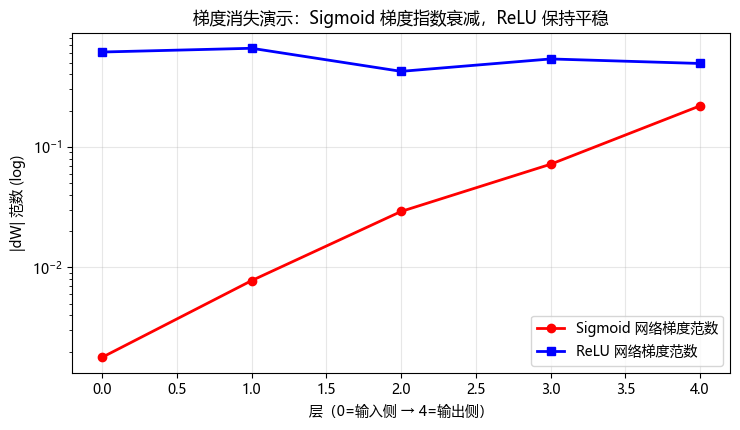

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(7.5, 4.4))
layers = np.arange(5)
ax.semilogy(layers, g_sig, 'ro-', lw=2, label='Sigmoid 网络梯度范数')
ax.semilogy(layers, g_relu, 'bs-', lw=2, label='ReLU 网络梯度范数')
ax.set_xlabel('层（0=输入侧 → 4=输出侧）'); ax.set_ylabel('|dW| 范数 (log)')
ax.set_title('梯度消失演示：Sigmoid 梯度指数衰减，ReLU 保持平稳', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 总结

- **激活函数**：非线性是深度的来源；ReLU 求导便宜且梯度不衰减，Sigmoid/Tanh 会饱和（导数→0）。
- **反向传播** = 链式法则：`dx = dy@Wᵀ`、`dW = xᵀ@dy`、`db = Σdy`，缓存前向中间量即可逐层回传。
- **优化器**：SGD 朴素、Momentum 加惯性、Adam 自适应步长——手搓实现与公式一一对应。
- **梯度消失**：深层网络慎用饱和激活，所以现代模型用 **RMSNorm + GELU/SiLU（SwiGLU）**（第 4/5 讲）。
- **与后面内容的联系**：Transformer 的 FFN 就是本讲的 MLP（第 4 讲手搓 + SwiGLU）；MiniMind 训练就是"前向 → 反传 → AdamW"（第 9 讲与 trainer/ 目录）；位置编码/注意力都是搭在"神经网络能学"这个基础上的。
